In [2]:
import pandas as pd
from pathlib import Path
import numpy as np
import time
import os
import statsmodels
import seaborn as sns
import matplotlib.pyplot as plt
import glob
from scipy import stats
import pingouin as pg
from scipy.stats import zscore
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


In [3]:
file_path = '/Users/audrey-annebeaudry/Desktop/Final_folder_VS/VS_results.csv'
vs_eeg = pd.read_csv(file_path)
vs_eeg

,subject,diagnosis,set_size,N1_amp,N1_lat,N1_chan,P3b_amp,P3b_lat,P3b_chan,alpha_power,gamma_power
0,0171M1,control,5,-2.693449e-06,0.095,E59,0.000003,0.355,E92,5.320556e-11,4.357310e-11
1,0171M1,control,9,-1.320499e-06,0.131,E92,0.000003,0.349,E87,4.504331e-11,4.186868e-11
2,0171M1,control,13,-9.898812e-07,0.134,E92,0.000005,0.448,E59,4.939756e-11,4.566363e-11
3,0131P,asd,5,-4.085812e-06,0.090,E92,0.000032,0.323,E59,2.201703e-09,7.876936e-11
4,0131P,asd,9,-8.019594e-06,0.080,E92,0.000028,0.317,E59,1.502232e-09,7.606831e-11
...,...,...,...,...,...,...,...,...,...,...,...
283,0162P,asd,9,-6.188868e-06,0.130,E53,0.000014,0.300,E92,1.482893e-09,6.939865e-11
284,0162P,asd,13,-6.349377e-06,0.089,E59,0.000010,0.426,E92,1.374909e-09,5.661023e-11
285,1052S1,control,5,-2.810581e-06,0.130,E53,0.000040,0.309,E59,2.653518e-09,1.135784e-10
286,1052S1,control,9,-2.087018e-05,0.080,E59,0.000035,0.403,E59,1.709421e-09,1.631741e-10


In [10]:
# Load all the files
vs_p = glob.glob('/Users/audrey-annebeaudry/Desktop/OneDrive_1_2025-01-12/experimental_files-2/*.txt')
vs_control = glob.glob('/Users/audrey-annebeaudry/Desktop/OneDrive_1_2025-01-12/control_files/*.txt')
all_files = vs_control + vs_p
go_files = all_files
len(all_files)
df = []
for file in all_files:
    file_name = file.split('/')[-1]
    file_name = "_".join(file_name.split('_')[:-1])
    subject_df = pd.read_csv(file, delimiter = "\t")
    subject_df['subject'] = file_name
    df.append(subject_df)
df = pd.concat(df, axis=0)
df

,Session_Name_,Trial_Index_,Trial_Recycled_,VS_SAC_RT,VS_VALID,sub_task_blocking,task,condition,detail,dl_video,vs_location_list,subject
0,023_vs_1,1,False,301,True,1,VS,Five,Single_Slice,Blank.mov,"(7, 2, 9, 14, 4)",Q1K_023_Z
1,023_vs_1,2,False,779,True,2,VS,Nine,Single_Slice,Blank.mov,"(1, 15, 2, 10, 6, 11, 7, 4, 16)",Q1K_023_Z
2,023_vs_1,3,False,-1,False,3,VS,Thirteen,Single_Slice,Blank.mov,"(3, 9, 14, 15, 12, 4, 10, 16, 1, 5, 8, 6, 11)",Q1K_023_Z
3,023_vs_1,4,False,248,True,4,VS,Five,Single_Apple,Blank.mov,"(10, 0, 14, 3, 2)",Q1K_023_Z
4,023_vs_1,5,False,3534,True,5,VS,Nine,Single_Apple,Blank.mov,"(3, 10, 0, 13, 9, 16, 14, 5, 7)",Q1K_023_Z
...,...,...,...,...,...,...,...,...,...,...,...,...
25,Q1121_M1,26,False,170,True,7,VS,Nine,Conjunction,Blank.mov,"(0, 3, 11, 13, 7, 8, 5, 1, 6)",1121M1
26,Q1121_M1,27,False,199,True,7,VS,Nine,Conjunction,Blank.mov,"(13, 8, 7, 5, 0, 4, 16, 11, 1)",1121M1
27,Q1121_M1,28,False,229,True,7,VS,Thirteen,Conjunction,Blank.mov,"(15, 9, 5, 8, 0, 11, 12, 4, 7, 6, 13, 2, 14)",1121M1
28,Q1121_M1,29,False,258,True,7,VS,Thirteen,Conjunction,Blank.mov,"(6, 13, 12, 14, 15, 16, 4, 11, 3, 2, 8, 1, 9)",1121M1


In [11]:
## keep only the relevant columns
df["condition"] = df["condition"].replace({"Five": "5", "Nine": "9", "Thirteen":"13"})
df = df[["subject", "condition", "VS_SAC_RT", "VS_VALID", "vs_location_list"]]
df

,subject,condition,VS_SAC_RT,VS_VALID,vs_location_list
0,Q1K_023_Z,5,301,True,"(7, 2, 9, 14, 4)"
1,Q1K_023_Z,9,779,True,"(1, 15, 2, 10, 6, 11, 7, 4, 16)"
2,Q1K_023_Z,13,-1,False,"(3, 9, 14, 15, 12, 4, 10, 16, 1, 5, 8, 6, 11)"
3,Q1K_023_Z,5,248,True,"(10, 0, 14, 3, 2)"
4,Q1K_023_Z,9,3534,True,"(3, 10, 0, 13, 9, 16, 14, 5, 7)"
...,...,...,...,...,...
25,1121M1,9,170,True,"(0, 3, 11, 13, 7, 8, 5, 1, 6)"
26,1121M1,9,199,True,"(13, 8, 7, 5, 0, 4, 16, 11, 1)"
27,1121M1,13,229,True,"(15, 9, 5, 8, 0, 11, 12, 4, 7, 6, 13, 2, 14)"
28,1121M1,13,258,True,"(6, 13, 12, 14, 15, 16, 4, 11, 3, 2, 8, 1, 9)"


In [12]:
# Filter out invalid trials: VS_VALID is False or RT is -1
df_valid = df[(df['VS_VALID'] == True) & (df['VS_SAC_RT'] > 0)]

# Group by subject and detail, then compute mean RT
df_avg_rt = df_valid.groupby(['subject', 'condition'], as_index=False)['VS_SAC_RT'].mean()
# Step 2: Rename column
df_avg_rt.rename(columns={'condition': 'set_size'}, inplace=True)

## Step 3: Map condition values
#df_avg_rt['set_size'] = df_avg_rt['set_size'].map({
#    'Single': 'single_search',
#    'Conjunction': 'conjunction_search'
#})

In [13]:
df_avg_rt


,subject,set_size,VS_SAC_RT
0,0042P,13,679.3
1,0042P,5,454.3
2,0042P,9,430.9
3,0062P,13,878.4
4,0062P,5,1772.0
...,...,...,...
388,Q1K_052_Z,5,521.777778
389,Q1K_052_Z,9,510.2
390,Q1K_096_Z,13,365.8
391,Q1K_096_Z,5,542.7


In [15]:
vs_eeg['set_size'] = vs_eeg['set_size'].astype(str)
df_avg_rt['set_size'] = df_avg_rt['set_size'].astype(str)
vs_merged = pd.merge(vs_eeg, df_avg_rt, on=['subject', 'set_size'], how='left')


In [16]:
vs_merged

,subject,diagnosis,set_size,N1_amp,N1_lat,N1_chan,P3b_amp,P3b_lat,P3b_chan,alpha_power,gamma_power,VS_SAC_RT
0,0171M1,control,5,-2.693449e-06,0.095,E59,0.000003,0.355,E92,5.320556e-11,4.357310e-11,513.9
1,0171M1,control,9,-1.320499e-06,0.131,E92,0.000003,0.349,E87,4.504331e-11,4.186868e-11,581.4
2,0171M1,control,13,-9.898812e-07,0.134,E92,0.000005,0.448,E59,4.939756e-11,4.566363e-11,562.9
3,0131P,asd,5,-4.085812e-06,0.090,E92,0.000032,0.323,E59,2.201703e-09,7.876936e-11,1167.777778
4,0131P,asd,9,-8.019594e-06,0.080,E92,0.000028,0.317,E59,1.502232e-09,7.606831e-11,707.625
...,...,...,...,...,...,...,...,...,...,...,...,...
283,0162P,asd,9,-6.188868e-06,0.130,E53,0.000014,0.300,E92,1.482893e-09,6.939865e-11,625.9
284,0162P,asd,13,-6.349377e-06,0.089,E59,0.000010,0.426,E92,1.374909e-09,5.661023e-11,419.4
285,1052S1,control,5,-2.810581e-06,0.130,E53,0.000040,0.309,E59,2.653518e-09,1.135784e-10,455.2
286,1052S1,control,9,-2.087018e-05,0.080,E59,0.000035,0.403,E59,1.709421e-09,1.631741e-10,521.0


## Demographics

In [18]:
# Load demographic data

demo_df = pd.read_csv("/Users/audrey-annebeaudry/Desktop/Final_folder_VS/q1k_attempted_demographic_ouputs_2025_07_12.csv")

In [20]:
demo_df['bids_id'] = demo_df['bids_id'].str.replace('sub-', '', regex=False)

In [29]:
demo_df

,eeg_age,group,site,eeg_sex,asd,bids_id,adhd,age_group,diagnosis_group
3,36.206082,proband,hsj,1,0.0,0104P,1.0,adult,control
27,8.432640,proband,hsj,1,0.0,0131P,1.0,child,control
32,32.501694,mother,hsj,1,0.0,0134M1,0.0,adult,control
33,34.615358,father,hsj,2,0.0,0134F1,1.0,adult,control
34,32.608472,proband,hsj,1,1.0,0146P,1.0,adult,control
46,12.996845,proband,hsj,2,1.0,0162P,1.0,child,control
47,12.996845,sibling,hsj,1,0.0,0162S1,0.0,child,control
49,12.309516,proband,mni,2,1.0,0171P,0.0,child,control
50,40.208788,mother,mni,1,0.0,0171M1,0.0,adult,control
52,40.208788,father,mni,2,0.0,0171F1,0.0,adult,control


In [21]:
# keep only the subjects that are in the vs_merged 
demo_df = demo_df[demo_df['bids_id'].isin(vs_merged['subject'])]

In [22]:
# Keep important columns
demo_df = demo_df[["eeg_age", "group", "site", "eeg_sex", "asd",  "bids_id", "adhd"]]

In [23]:
demo_df["asd"] = demo_df["asd"].fillna("Unknown")

In [24]:
# Create column for age group
demo_df['age_group'] = pd.cut(demo_df['eeg_age'], bins=[0, 18, 100], labels=['child', 'adult'])
unknown_asd = demo_df[demo_df['asd'] == 'Unknown']  # Filter rows where 'asd' is 'unknown'
demo_df = demo_df[demo_df['asd'] != 'Unknown']

In [30]:
def assign_diagnosis_group(row):
    if row['asd'] == 1:  # If ASD is 1, assign 'asd' regardless of ADHD
        return 'asd'
    elif row['adhd'] == 1:  # If ADHD is 1, assign 'adhd'
        return 'adhd'
    else:
        return 'control'  # Default to control if neither ASD nor ADHD is 1

# Apply the function to each row to create the 'diagnosis_group' column
demo_df.loc[:, 'diagnosis_group'] = demo_df.apply(assign_diagnosis_group, axis=1)

In [31]:
# Assuming demo_df is already defined as the demographic dataframe

# Summarize data by diagnosis groups
summary_table = demo_df.groupby("diagnosis_group").agg(
    n=("diagnosis_group", "count"),
    male=("eeg_sex", lambda x: (x == "male").sum()),
    female=("eeg_sex", lambda x: (x == "female").sum()),
    mean_age=("eeg_age", "mean"),
    std_age=("eeg_age", "std"),
    hsj=("site", lambda x: (x == "hsj").sum()),
    mni=("site", lambda x: (x == "mni").sum()),
    adults=("age_group", lambda x: (x == "adult").sum()),
    children=("age_group", lambda x: (x == "child").sum()),
).reset_index()

# Add combined row for all participants
all_participants = {
    "diagnosis_group": "combined",
    "n": summary_table["n"].sum(),
    "male": summary_table["male"].sum(),
    "female": summary_table["female"].sum(),
    "mean_age": demo_df["eeg_age"].mean(),
    "std_age": demo_df["eeg_age"].std(),
    "hsj": summary_table["hsj"].sum(),
    "mni": summary_table["mni"].sum(),
    "adults": summary_table["adults"].sum(),
    "children": summary_table["children"].sum(),
}

summary_table = pd.concat(
    [pd.DataFrame([all_participants]), summary_table], ignore_index=True
)

# Create combined and percentage columns
summary_table["sex (M:F)"] = summary_table["male"].astype(str) + ":" + summary_table["female"].astype(str)
summary_table["sex % (M:F)"] = (
    (summary_table["male"] / summary_table["n"] * 100).round(2).astype(str)
    + ":"
    + (summary_table["female"] / summary_table["n"] * 100).round(2).astype(str)
)

summary_table["site (HSJ:MNI)"] = summary_table["hsj"].astype(str) + ":" + summary_table["mni"].astype(str)
summary_table["site % (HSJ:MNI)"] = (
    (summary_table["hsj"] / summary_table["n"] * 100).round(2).astype(str)
    + ":"
    + (summary_table["mni"] / summary_table["n"] * 100).round(2).astype(str)
)

# Drop intermediate columns to keep the table clean
summary_table.drop(columns=["male", "female", "hsj", "mni"], inplace=True)

# Rename columns for better clarity
summary_table.rename(
    columns={
        "diagnosis_group": "Diagnosis Group",
        "n": "Total Participants",
        "mean_age": "Mean Age",
        "std_age": "Age SD",
        "adults": "Adults",
        "children": "Children",
    },
    inplace=True,
)
summary_table=summary_table.round(2)

In [32]:
summary_table

,Diagnosis Group,Total Participants,Mean Age,Age SD,Adults,Children,sex (M:F),sex % (M:F),site (HSJ:MNI),site % (HSJ:MNI)
0,combined,56,25.43,16.10,27,29,0:0,0.0:0.0,28:28,50.0:50.0
1,adhd,10,20.11,13.77,3,7,0:0,0.0:0.0,9:1,90.0:10.0
2,asd,20,16.01,8.51,4,16,0:0,0.0:0.0,11:9,55.0:45.0
3,control,26,34.73,16.57,20,6,0:0,0.0:0.0,8:18,30.77:69.23


## Statistics with EEG + ET

In [35]:
vs_merged = vs_merged.dropna()
vs_merged

,subject,diagnosis,set_size,N1_amp,N1_lat,N1_chan,P3b_amp,P3b_lat,P3b_chan,alpha_power,gamma_power,VS_SAC_RT
0,0171M1,control,5,-2.693449e-06,0.095,E59,0.000003,0.355,E92,5.320556e-11,4.357310e-11,513.9
1,0171M1,control,9,-1.320499e-06,0.131,E92,0.000003,0.349,E87,4.504331e-11,4.186868e-11,581.4
2,0171M1,control,13,-9.898812e-07,0.134,E92,0.000005,0.448,E59,4.939756e-11,4.566363e-11,562.9
3,0131P,asd,5,-4.085812e-06,0.090,E92,0.000032,0.323,E59,2.201703e-09,7.876936e-11,1167.777778
4,0131P,asd,9,-8.019594e-06,0.080,E92,0.000028,0.317,E59,1.502232e-09,7.606831e-11,707.625
...,...,...,...,...,...,...,...,...,...,...,...,...
283,0162P,asd,9,-6.188868e-06,0.130,E53,0.000014,0.300,E92,1.482893e-09,6.939865e-11,625.9
284,0162P,asd,13,-6.349377e-06,0.089,E59,0.000010,0.426,E92,1.374909e-09,5.661023e-11,419.4
285,1052S1,control,5,-2.810581e-06,0.130,E53,0.000040,0.309,E59,2.653518e-09,1.135784e-10,455.2
286,1052S1,control,9,-2.087018e-05,0.080,E59,0.000035,0.403,E59,1.709421e-09,1.631741e-10,521.0


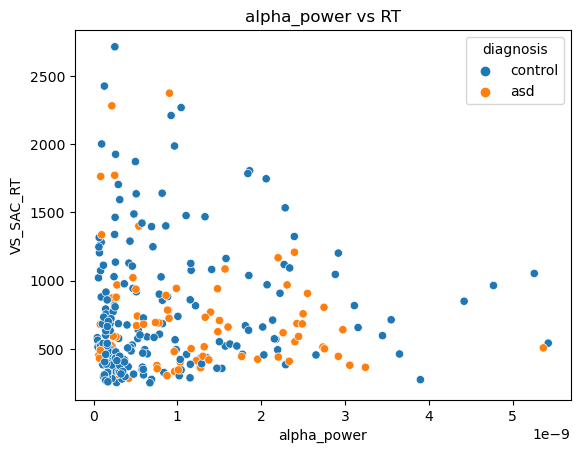

Spearman correlation: rho = 0.11, p = 0.079


In [34]:
# Plot relationship
sns.scatterplot(data=vs_merged, x='alpha_power', y='VS_SAC_RT', hue='diagnosis')
plt.title('alpha_power vs RT')
plt.show()

# Spearman correlation
rho, p = spearmanr(vs_merged['alpha_power'], vs_merged['VS_SAC_RT'])
print(f"Spearman correlation: rho = {rho:.2f}, p = {p:.3f}")

In [40]:
plot_df = vs_merged.copy()
# Convert to numeric (forces strings to NaN if they sneak in)
plot_df['alpha_power'] = pd.to_numeric(plot_df['alpha_power'], errors='coerce')
plot_df['VS_SAC_RT'] = pd.to_numeric(plot_df['VS_SAC_RT'], errors='coerce')
plot_df['set_size'] = pd.to_numeric(plot_df['set_size'], errors='coerce')


# Drop rows with any NaNs in those key columns
plot_df = plot_df.dropna(subset=['alpha_power', 'VS_SAC_RT', 'set_size'])

In [45]:
plot_df = vs_merged.copy()

# Force critical columns to numeric and drop rows with non-finite values
cols_to_check = ['alpha_power', 'VS_SAC_RT']
for col in cols_to_check:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

# Drop rows with any NaNs in alpha_power or RT
plot_df = plot_df.dropna(subset=cols_to_check)

# Double-check all values are finite numbers
import numpy as np
plot_df = plot_df[np.isfinite(plot_df['alpha_power']) & np.isfinite(plot_df['VS_SAC_RT'])]

plot_df['alpha_power'] =  np.log(plot_df['alpha_power'])
plot_df['gamma_power'] =  np.log(plot_df['gamma_power'])
plot_df['N1_amp'] = np.log(np.abs(plot_df['N1_amp']))#log of a negative = NaN (should we make them positive value) = do the absolute value
plot_df['P3b_amp'] =  np.log(plot_df['P3b_amp']) 
plot_df

,subject,diagnosis,set_size,N1_amp,N1_lat,N1_chan,P3b_amp,P3b_lat,P3b_chan,alpha_power,gamma_power,VS_SAC_RT
0,0171M1,control,5,-12.824688,0.095,E59,-12.726260,0.355,E92,-23.656858,-23.856581,513.900000
1,0171M1,control,9,-13.537501,0.131,E92,-12.862242,0.349,E87,-23.823397,-23.896483,581.400000
2,0171M1,control,13,-13.825681,0.134,E92,-12.189099,0.448,E59,-23.731120,-23.809719,562.900000
3,0131P,asd,5,-12.407990,0.090,E92,-10.362046,0.323,E59,-19.934035,-23.264497,1167.777778
4,0131P,asd,9,-11.733623,0.080,E92,-10.496700,0.317,E59,-20.316314,-23.299389,707.625000
...,...,...,...,...,...,...,...,...,...,...,...,...
283,0162P,asd,9,-11.992758,0.130,E53,-11.153373,0.300,E92,-20.329271,-23.391154,625.900000
284,0162P,asd,13,-11.967154,0.089,E59,-11.549901,0.426,E92,-20.404878,-23.594831,419.400000
285,1052S1,control,5,-12.782119,0.130,E53,-10.138520,0.309,E59,-19.747380,-22.898527,455.200000
286,1052S1,control,9,-10.777189,0.080,E59,-10.273729,0.403,E59,-20.187111,-22.536203,521.000000


In [62]:
vs_merged['VS_SAC_RT'] = pd.to_numeric(vs_merged['VS_SAC_RT'], errors='coerce')
vs_merged['gamma_power'] = pd.to_numeric(vs_merged['gamma_power'], errors='coerce')

vs_merged['N1_amp'] = pd.to_numeric(vs_merged['N1_amp'], errors='coerce')
vs_merged['P3b_amp'] = pd.to_numeric(vs_merged['P3b_amp'], errors='coerce')
print(vs_merged[['alpha_power', 'VS_SAC_RT', 'gamma_power','diagnosis', 'N1_amp', 'P3b_amp']].dtypes)

alpha_power    float64
VS_SAC_RT      float64
gamma_power    float64
diagnosis       object
N1_amp         float64
P3b_amp        float64
dtype: object


<Figure size 800x600 with 0 Axes>

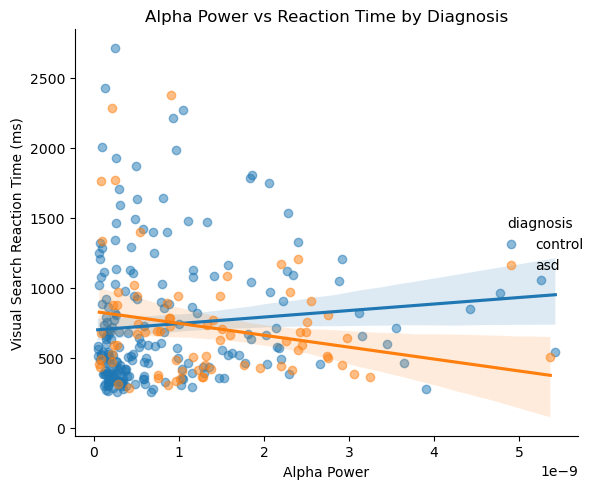

In [63]:
plt.figure(figsize=(8, 6))
sns.lmplot(data=vs_merged, x='alpha_power', y='VS_SAC_RT', hue='diagnosis', scatter_kws={'alpha':0.5})
plt.title('Alpha Power vs Reaction Time by Diagnosis')
plt.xlabel('Alpha Power')
plt.ylabel('Visual Search Reaction Time (ms)')
plt.tight_layout()
plt.show()


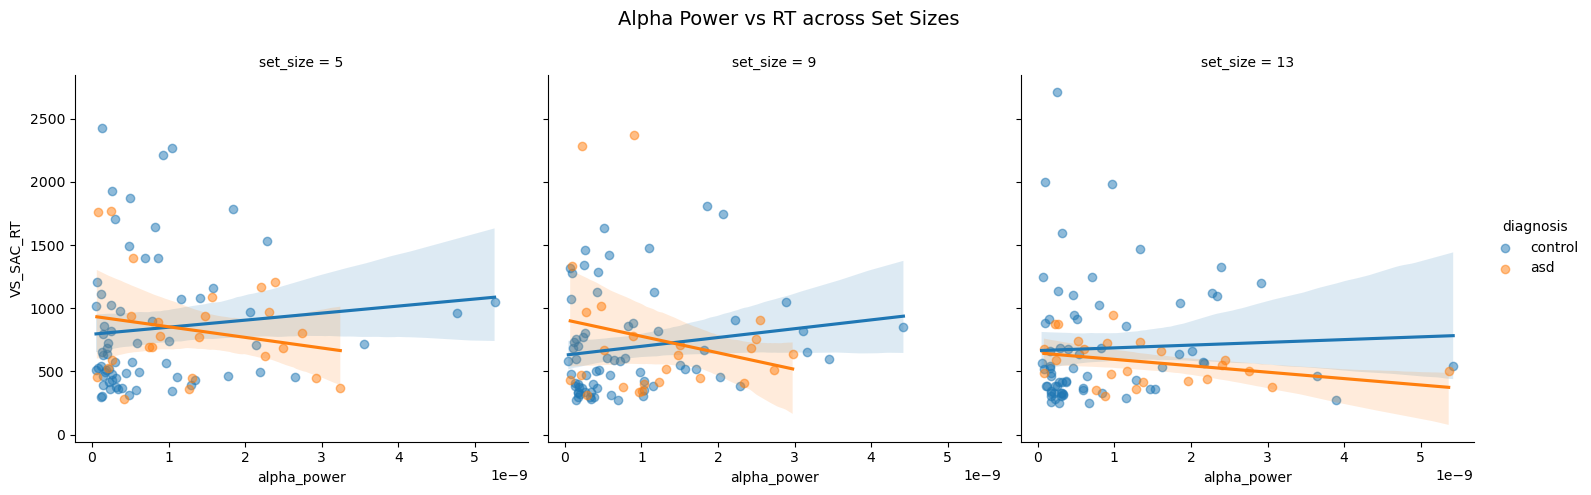

In [64]:
sns.lmplot(
    data=vs_merged, x='alpha_power', y='VS_SAC_RT', hue='diagnosis',
    col='set_size', scatter_kws={'alpha': 0.5}, height=5, aspect=1
)
plt.subplots_adjust(top=0.85)
plt.suptitle('Alpha Power vs RT across Set Sizes', fontsize=14)
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

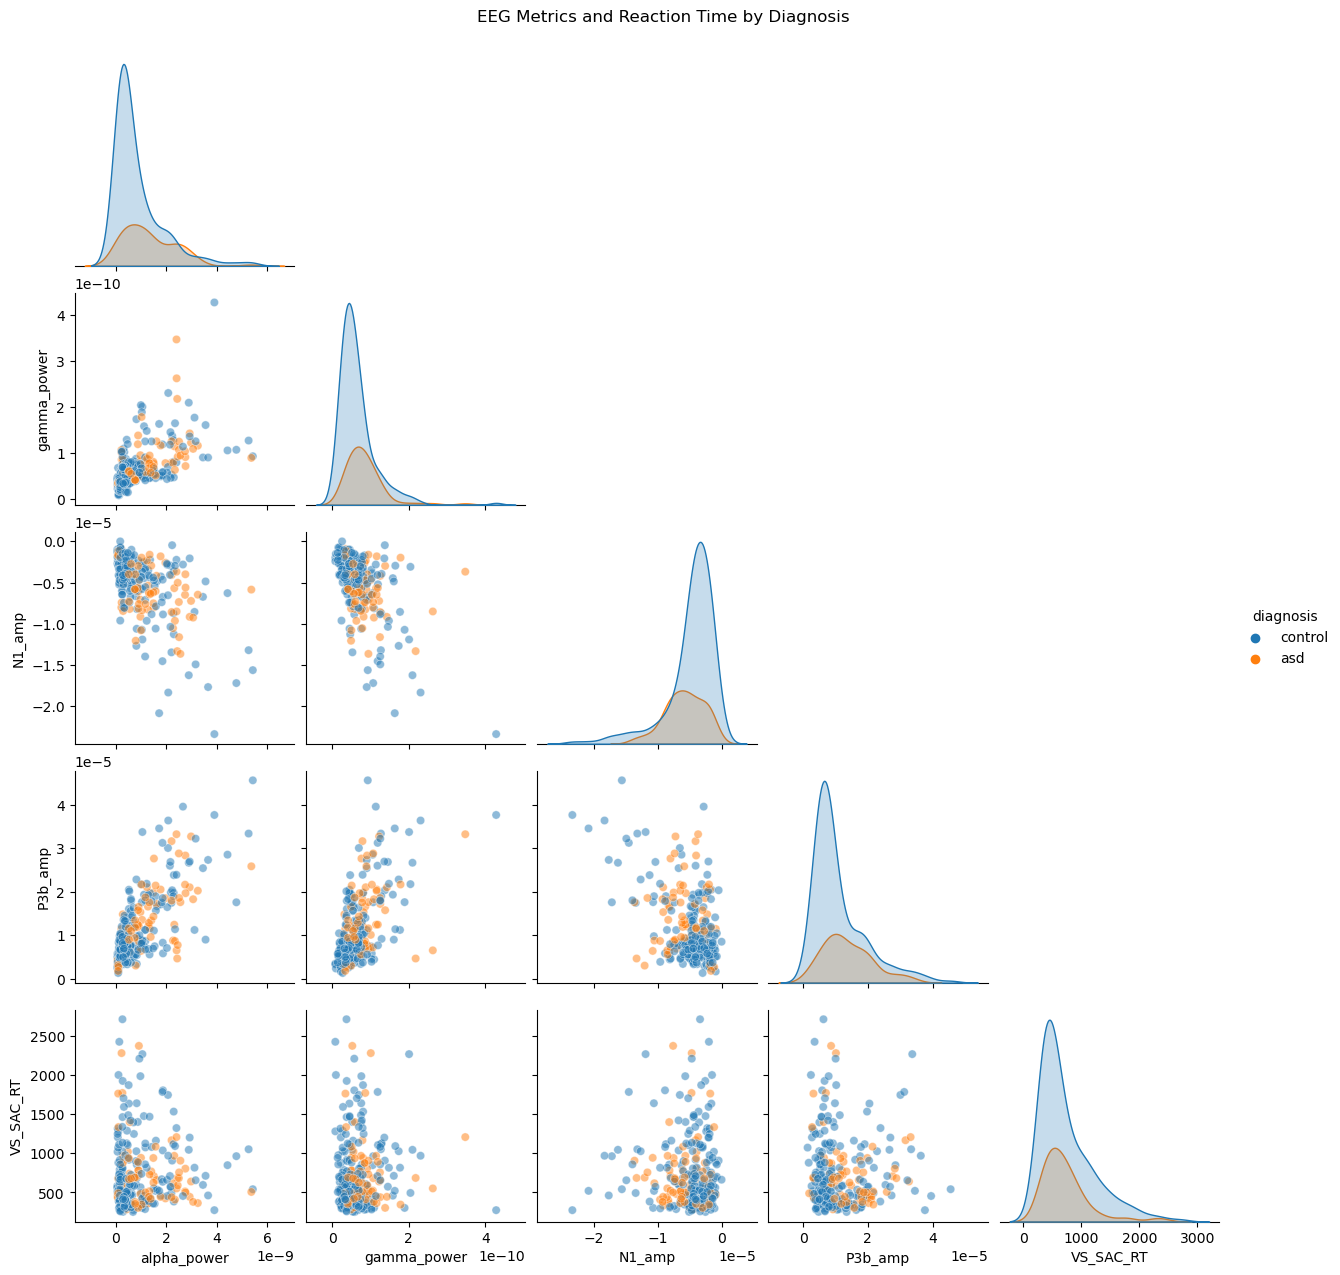

In [65]:
sns.pairplot(
    vs_merged,
    vars=['alpha_power', 'gamma_power', 'N1_amp', 'P3b_amp', 'VS_SAC_RT'],
    hue='diagnosis', corner=True, plot_kws={'alpha': 0.5}
)
plt.suptitle('EEG Metrics and Reaction Time by Diagnosis', y=1.02)
plt.show()


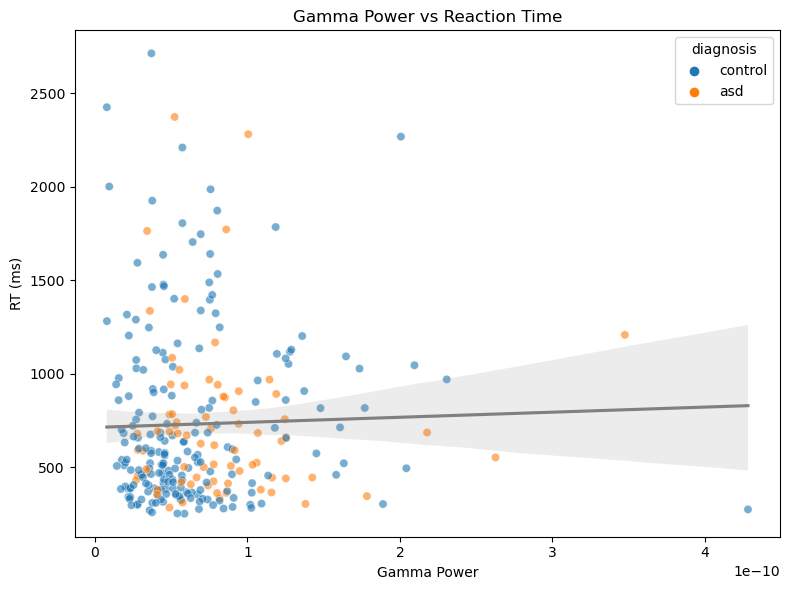

In [66]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=vs_merged, x='gamma_power', y='VS_SAC_RT', hue='diagnosis', alpha=0.6)
sns.regplot(data=vs_merged, x='gamma_power', y='VS_SAC_RT', scatter=False, color='gray')
plt.title('Gamma Power vs Reaction Time')
plt.xlabel('Gamma Power')
plt.ylabel('RT (ms)')
plt.tight_layout()
plt.show()

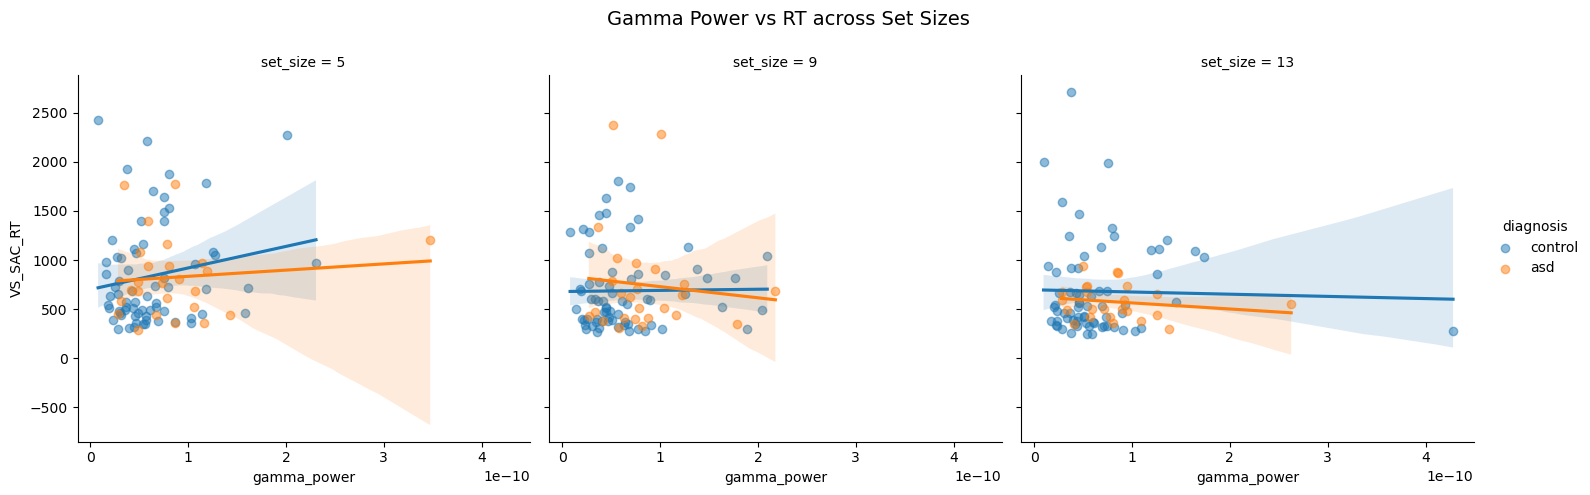

In [74]:
sns.lmplot(
    data=vs_merged, x='gamma_power', y='VS_SAC_RT', hue='diagnosis',
    col='set_size', scatter_kws={'alpha': 0.5}, height=5, aspect=1
)
plt.subplots_adjust(top=0.85)
plt.suptitle('Gamma Power vs RT across Set Sizes', fontsize=14)
plt.show()

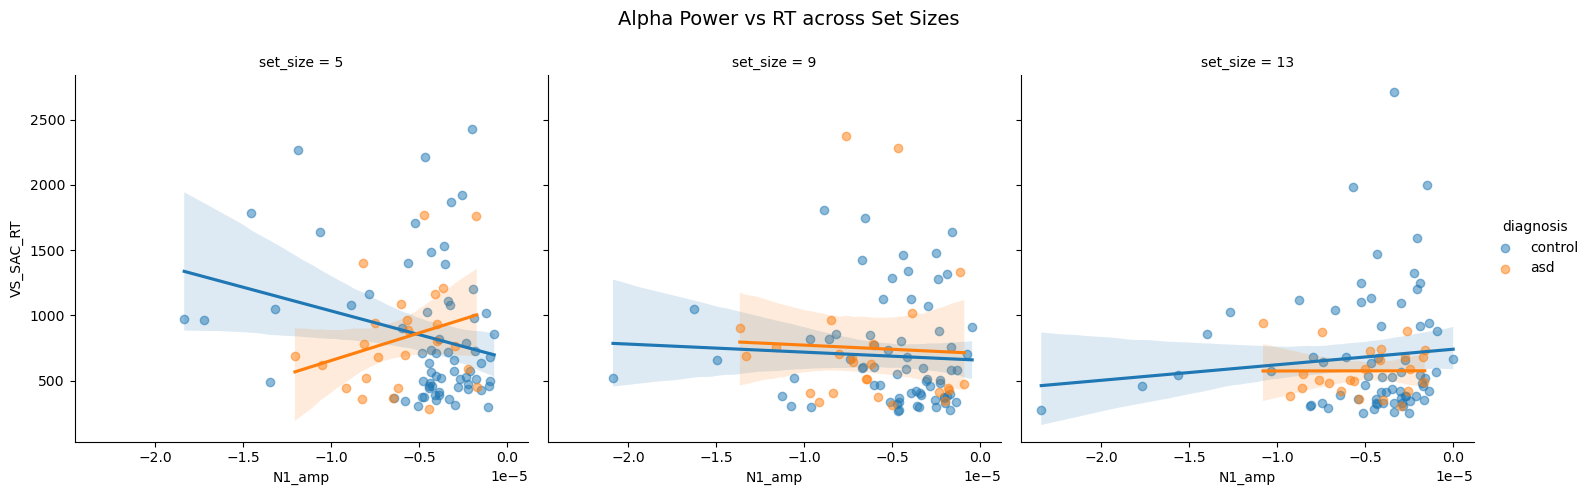

In [71]:
sns.lmplot(
    data=vs_merged, x='N1_amp', y='VS_SAC_RT', hue='diagnosis',
    col='set_size', scatter_kws={'alpha': 0.5}, height=5, aspect=1
)
plt.subplots_adjust(top=0.85)
plt.suptitle('N1 amp vs RT across Set Sizes', fontsize=14)
plt.show()

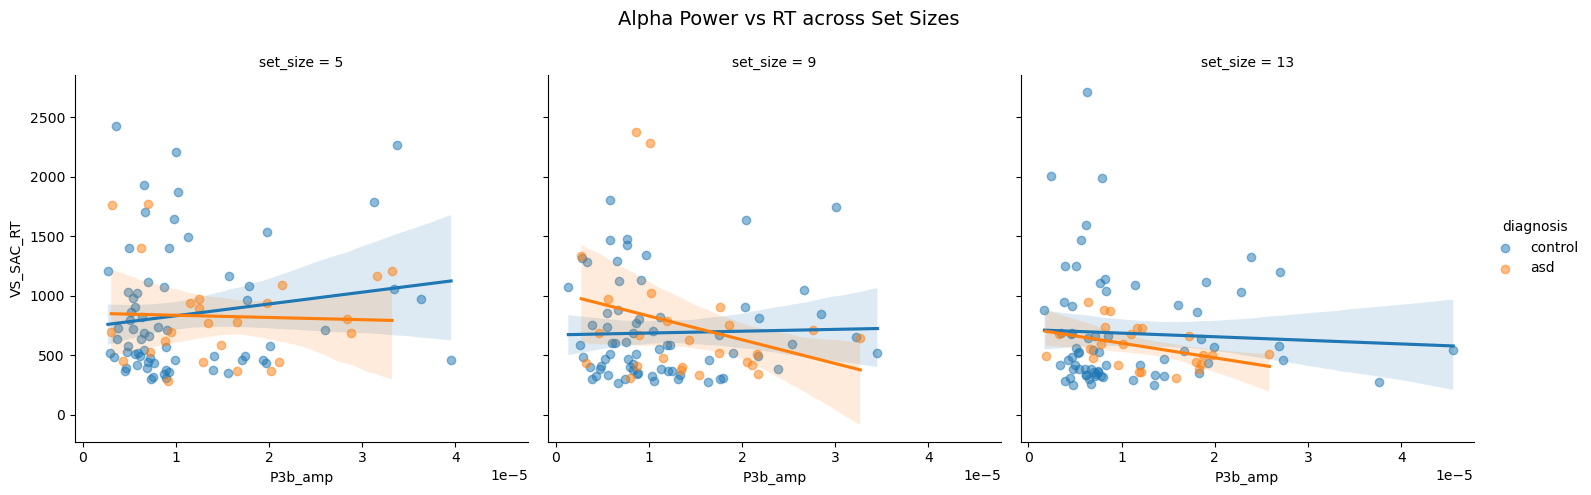

In [73]:
sns.lmplot(
    data=vs_merged, x='P3b_amp', y='VS_SAC_RT', hue='diagnosis',
    col='set_size', scatter_kws={'alpha': 0.5}, height=5, aspect=1
)
plt.subplots_adjust(top=0.85)
plt.suptitle('P3B amplitude vs RT across Set Sizes', fontsize=14)
plt.show()